Using Device: cpu
Model Loaded Successfully


100%|██████████| 9497/9497 [05:40<00:00, 27.92it/s]


Dataset Size: 7461


c:\Users\bhanu\Downloads\StructCompose\venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\bhanu\Downloads\StructCompose\venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\bhanu\Downloads\StructCompose\venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\bhanu\Downloads\StructCompose\venv\Lib\site-packages\sklearn\metrics\_classification.py:991: RuntimeWarning: invalid value enco


===== MODEL EVALUATION =====
Loss: 0.0
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
Balanced Acc: 1.0
MCC: 0.0
Kappa: nan


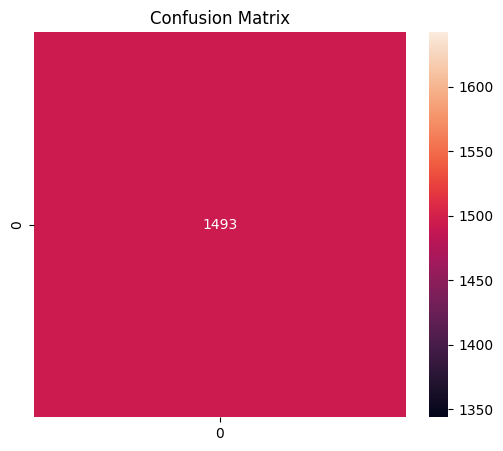

In [10]:
# =========================================================
# IMPORTS
# =========================================================

import os
import sys
import cv2
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import networkx as nx

from tqdm import tqdm
from torchvision import transforms
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score
)

# =========================================================
# DEVICE
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# =========================================================
# LOAD MODEL
# =========================================================

from src.models.hybrid_model import HybridComposeNet

model = HybridComposeNet()

pth_path = r"C:\Users\bhanu\Downloads\StructCompose\checkpoints\hybrid_compose_net.pth"

model.load_state_dict(torch.load(pth_path, map_location=device))
model.to(device)
model.eval()

print("Model Loaded Successfully")

# =========================================================
# IMAGE TRANSFORM (FIXED)
# =========================================================

image_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# =========================================================
# CUSTOM DATA CLASS
# =========================================================

class HybridData(Data):
    def __cat_dim__(self, key, value, *args, **kwargs):
        if key == "image":
            return None
        return super().__cat_dim__(key, value, *args, **kwargs)

# =========================================================
# SAMPLE CREATION
# =========================================================

def create_hybrid_sample(image_path, graph_path, target):

    img = cv2.imread(image_path)
    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    image_tensor = image_transform(img)

    # GRAPH LOAD
    with open(graph_path, "r") as f:
        graph_data = json.load(f)

    G = nx.node_link_graph(graph_data)

    node_features = []

    for _, attrs in G.nodes(data=True):
        node_features.append([
            float(attrs.get("center_x", 0)),
            float(attrs.get("center_y", 0)),
            float(attrs.get("area", 0)),
            float(attrs.get("confidence", 0))
        ])

    if len(node_features) == 0:
        return None

    x = torch.tensor(node_features, dtype=torch.float)

    edge_index = []
    for u, v in G.edges():
        edge_index.append([u, v])
        edge_index.append([v, u])

    if len(edge_index) == 0:
        for i in range(len(node_features)):
            edge_index.append([i, i])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    # IMPORTANT FIX: classification-safe label
    y = torch.tensor([int(target)], dtype=torch.long)

    data = HybridData(x=x, edge_index=edge_index, y=y)
    data.image = image_tensor

    return data

# =========================================================
# DATASET BUILD
# =========================================================

IMAGE_DIR = r"C:\Users\bhanu\Downloads\StructCompose\data\raw\CADB\images"

dataset_df = pd.read_csv("../data/processed/full_composition_dataset.csv")

hybrid_dataset = []

for _, row in tqdm(dataset_df.iterrows(), total=len(dataset_df)):

    image_path = os.path.join(IMAGE_DIR, row["image_name"])
    graph_path = "../data/processed/graphs/" + row["image_name"] + ".json"

    if not os.path.exists(graph_path):
        continue

    try:
        sample = create_hybrid_sample(
            image_path,
            graph_path,
            row["edge_density"]
        )

        if sample is not None:
            hybrid_dataset.append(sample)

    except Exception as e:
        print("Error:", row["image_name"], e)

print("Dataset Size:", len(hybrid_dataset))

# =========================================================
# SPLIT
# =========================================================

train_data, test_data = train_test_split(
    hybrid_dataset,
    test_size=0.2,
    random_state=42
)

train_loader = DataLoader(train_data, batch_size=8, shuffle=True)
test_loader = DataLoader(test_data, batch_size=8)

# =========================================================
# LOSS (FIXED FOR CLASSIFICATION)
# =========================================================

criterion = torch.nn.CrossEntropyLoss()

# =========================================================
# EVALUATION LOOP
# =========================================================

all_preds = []
all_labels = []
all_probs = []
running_loss = 0

with torch.no_grad():

    for batch in test_loader:

        batch = batch.to(device)

        outputs = model(batch)

        # FIX: ensure correct shape
        if outputs.dim() == 1:
            outputs = outputs.unsqueeze(0)

        loss = criterion(outputs, batch.y)
        running_loss += loss.item()

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# =========================================================
# METRICS
# =========================================================

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

balanced_acc = balanced_accuracy_score(all_labels, all_preds)
mcc = matthews_corrcoef(all_labels, all_preds)
kappa = cohen_kappa_score(all_labels, all_preds)

avg_loss = running_loss / len(test_loader)

# =========================================================
# PRINT RESULTS
# =========================================================

print("\n===== MODEL EVALUATION =====")
print("Loss:", avg_loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("Balanced Acc:", balanced_acc)
print("MCC:", mcc)
print("Kappa:", kappa)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

# =========================================================
# ROC-AUC (SAFE)
# =========================================================

if len(np.unique(all_labels)) == 2:
    auc = roc_auc_score(all_labels, all_probs[:, 1])
    print("ROC-AUC:", auc)